In [1]:
# Temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# Makine Öğrenmesi (Scikit-Learn) kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Modeli dışa aktarmak için
import joblib

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları (Grafiklerin daha şık durması için)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Veri setini okuma
# Not: Notebook dosyamız 'notebooks' klasöründe olduğu için, 
# 'data' klasörüne ulaşmak adına '../' ile bir üst dizine çıkıyoruz.
df = pd.read_csv('../data/cleaned_sales.csv')

# Verinin başarıyla yüklendiğini kontrol edelim
display(df.head())
print("\n--- Veri Tipleri ---")
display(df.info())

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,26196.0,2,0.0,419136.0
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",73194.0,3,0.0,219582.0
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,1462.0,2,0.0,68714.0
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,9575775.0,5,45.0,-383031.0
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22368.0,2,2.0,25164.0



--- Veri Tipleri ---
<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9993 non-null   int64  
 1   Order_ID       9993 non-null   str    
 2   Order_Date     9993 non-null   str    
 3   Ship_Date      9993 non-null   str    
 4   Ship_Mode      9993 non-null   str    
 5   Customer_ID    9993 non-null   str    
 6   Customer_Name  9993 non-null   str    
 7   Segment        9993 non-null   str    
 8   Country        9993 non-null   str    
 9   City           9993 non-null   str    
 10  State          9993 non-null   str    
 11  Postal_Code    9993 non-null   int64  
 12  Region         9993 non-null   str    
 13  Product_ID     9993 non-null   str    
 14  Category       9993 non-null   str    
 15  Sub_Category   9993 non-null   str    
 16  Product_Name   9993 non-null   str    
 17  Sales          9993 non-null   float64
 1

None

In [2]:
# 1. Tarih sütununu string'den datetime formatına çeviriyoruz
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 2. Günlük satışları 'Ay Başı' (MS - Month Start) bazında toplayarak grupluyoruz
# Sadece Order_Date ve Sales sütunlarıyla yeni bir DataFrame oluşturuyoruz
monthly_sales = df.set_index('Order_Date').resample('MS')['Sales'].sum().reset_index()

# 3. Modele trendi öğretebilmek için 'Gecikmeli Özellik' (Lag Feature) ekliyoruz
# shift(1) fonksiyonu ile bir önceki ayın satış rakamını yeni bir sütuna kaydırıyoruz
monthly_sales['Prev_Month_Sales'] = monthly_sales['Sales'].shift(1)

# 4. En baştaki ilk ayın 'geçen ayı' olmadığı için Prev_Month_Sales değeri NaN (boş) çıkar. 
# Hata almamak için o ilk satırı siliyoruz.
monthly_sales = monthly_sales.dropna()

# Yeni hazırladığımız aylık tablonun ilk 5 satırını görelim
display(monthly_sales.head())

,Order_Date,Sales,Prev_Month_Sales
1,2011-02-01,1090093.0,2617974.0
2,2011-03-01,19889225.0,1090093.0
3,2011-04-01,8931683.0,19889225.0
4,2011-05-01,9349645.0,8931683.0
5,2011-06-01,18297753.0,9349645.0


In [3]:
# 3. Adımın eksik kalan kısmı: Tarih Parçalama (Feature Engineering)
monthly_sales['Year'] = monthly_sales['Order_Date'].dt.year
monthly_sales['Month'] = monthly_sales['Order_Date'].dt.month

# Yeni sütunların eklendiğini görmek için tablonun son haline bakalım
display(monthly_sales.head())

,Order_Date,Sales,Prev_Month_Sales,Year,Month
1,2011-02-01,1090093.0,2617974.0,2011,2
2,2011-03-01,19889225.0,1090093.0,2011,3
3,2011-04-01,8931683.0,19889225.0,2011,4
4,2011-05-01,9349645.0,8931683.0,2011,5
5,2011-06-01,18297753.0,9349645.0,2011,6


In [5]:
# --- ADIM 4: VERİYİ EĞİTİM VE TEST OLARAK AYIRMA ---
# Kronolojik olarak 2011-2013 yılları eğitim, 2014 yılı test olarak ayrılıyor
train_data = monthly_sales[monthly_sales['Order_Date'] < '2014-01-01']
test_data = monthly_sales[monthly_sales['Order_Date'] >= '2014-01-01']

# Modele öğreteceğimiz özellikler (Artık Ay ve Yıl bilgisi de var!)
features = ['Prev_Month_Sales', 'Month', 'Year']

X_train = train_data[features]
y_train = train_data['Sales']

X_test = test_data[features]
y_test = test_data['Sales']

# --- ADIM 5: MODEL SEÇİMİ VE EĞİTİLMESİ ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Tahmin yapıp başarıyı ölçelim
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("--- 4. VE 5. ADIMLAR TAMAMLANDI ---")
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f} Dolar")

--- 4. VE 5. ADIMLAR TAMAMLANDI ---
Ortalama Mutlak Hata (MAE): 6467060.98 Dolar


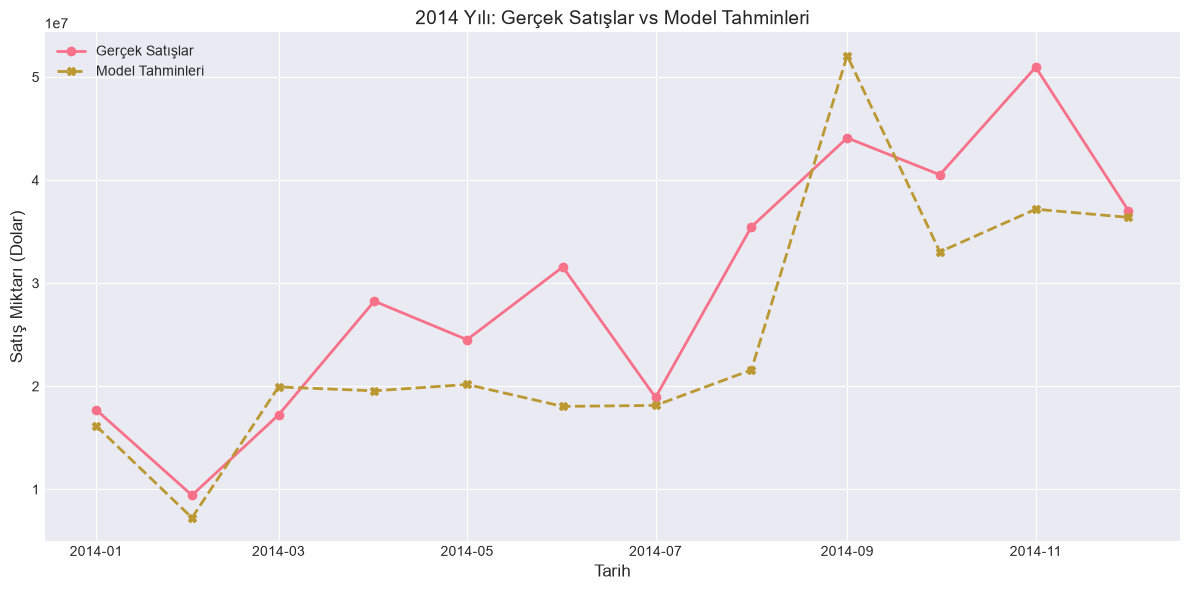

--- İŞLEM TAMAM ---
Harika! Modelin başarıyla paketlendi ve '../models/rf_sales_model.joblib' klasörüne kaydedildi.


In [6]:
import os
import matplotlib.pyplot as plt

# --- ADIM 6: GÖRSELLEŞTİRME ---
# Gerçek satışlar ile modelin tahminlerini aynı grafik üzerinde çizelim
plt.figure(figsize=(12, 6))
plt.plot(test_data['Order_Date'], y_test, label='Gerçek Satışlar', marker='o', linewidth=2)
plt.plot(test_data['Order_Date'], predictions, label='Model Tahminleri', marker='X', linestyle='--', linewidth=2)

plt.title('2014 Yılı: Gerçek Satışlar vs Model Tahminleri', fontsize=14)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Satış Miktarı (Dolar)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# --- ADIM 7: MODELİ DIŞA AKTARMA (EXPORT) ---
# Modelleri tutacağımız klasörü oluşturuyoruz (Eğer yoksa)
os.makedirs('../models', exist_ok=True)

# Eğittiğimiz bu modeli, Streamlit (Web) uygulamasında kullanmak üzere kaydediyoruz
model_path = '../models/rf_sales_model.joblib'
joblib.dump(model, model_path)

print(f"--- İŞLEM TAMAM ---")
print(f"Harika! Modelin başarıyla paketlendi ve '{model_path}' klasörüne kaydedildi.")